

1. **Realtime**（地图、风险分布、污染物对比）
2. **History**（趋势、热力、STL、季节性统计）
3. **Predict**（Prophet 预测、组件分解、模型指标）


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import STL

# Plotly notebook 渲染兼容：若缺少 nbformat，则自动回退到浏览器渲染
from plotly.basedatatypes import BaseFigure
_orig_show = BaseFigure.show

def _safe_show(self, *args, **kwargs):
    try:
        return _orig_show(self, *args, **kwargs)
    except ValueError as e:
        if "nbformat" in str(e):
            pio.renderers.default = "browser"
            print("Plotly inline renderer unavailable (nbformat missing). Switched to browser renderer.")
            return _orig_show(self, *args, **kwargs)
        raise

BaseFigure.show = _safe_show

print("Libraries loaded.")

Libraries loaded.


In [2]:
# ===== 参数区（答辩前可改） =====
CITY = "北京"
FORECAST_DAYS = 30
CP_SCALE = 0.05

# ===== 路径区（优先 tempo） =====
ROOT = Path(r"D:\Downloads\FYP CHINA\data")
TEMPO = ROOT / "tempo"
ACTIVE = TEMPO if TEMPO.exists() else ROOT

MASTER_DAILY = ACTIVE / "master_daily.csv"
DAILY_DIR = ACTIVE / "daily_cities"
CLEANED_DIR = ACTIVE / "cleaned_cities"
REALTIME_DIR = ROOT / "realtime"
CITY_GEO = ROOT / "city_geo.json"

print("ACTIVE DATA ROOT:", ACTIVE)
print("MASTER_DAILY:", MASTER_DAILY)

ACTIVE DATA ROOT: D:\Downloads\FYP CHINA\data\tempo
MASTER_DAILY: D:\Downloads\FYP CHINA\data\tempo\master_daily.csv


In [3]:
# 通用函数
AQI_LEVEL_ORDER = ["优", "良", "轻度污染", "中度污染", "重度污染", "严重污染", "无数据"]
AQI_LEVEL_COLOR = {
    "优": "#00e400",
    "良": "#ffff00",
    "轻度污染": "#ff9900",
    "中度污染": "#ff0000",
    "重度污染": "#99004c",
    "严重污染": "#7e0023",
    "无数据": "#888888",
}

AQI_LEVELS = [
    {"name": "优", "min": 0, "max": 50, "color": "rgba(0, 228, 0, 0.18)"},
    {"name": "良", "min": 51, "max": 100, "color": "rgba(255, 255, 0, 0.18)"},
    {"name": "轻度污染", "min": 101, "max": 150, "color": "rgba(255, 126, 0, 0.18)"},
    {"name": "中度污染", "min": 151, "max": 200, "color": "rgba(255, 0, 0, 0.16)"},
    {"name": "重度污染", "min": 201, "max": 300, "color": "rgba(153, 0, 76, 0.16)"},
    {"name": "严重污染", "min": 301, "max": 500, "color": "rgba(126, 0, 35, 0.16)"},
]

def get_aqi_level(aqi):
    if pd.isna(aqi):
        return "无数据"
    aqi = float(aqi)
    if aqi <= 50: return "优"
    if aqi <= 100: return "良"
    if aqi <= 150: return "轻度污染"
    if aqi <= 200: return "中度污染"
    if aqi <= 300: return "重度污染"
    return "严重污染"

def preprocess_for_prophet(df_city):
    dfc = df_city.copy()
    dfc["date"] = pd.to_datetime(dfc["date"], errors="coerce")
    dfc = dfc.dropna(subset=["date", "AQI"]).copy()
    dfc = dfc.groupby("date", as_index=False)["AQI"].mean()
    full = pd.date_range(dfc["date"].min(), dfc["date"].max(), freq="D")
    out = dfc.set_index("date").reindex(full).reset_index().rename(columns={"index": "ds", "AQI": "y"})
    out["y"] = out["y"].interpolate(method="linear")
    return out

print("Helper functions ready.")

Helper functions ready.


In [5]:
# 读取主数据 + 城市数据 + geo + realtime（若存在）
if not MASTER_DAILY.exists():
    raise FileNotFoundError(f"master file not found: {MASTER_DAILY}")

master = pd.read_csv(MASTER_DAILY)
master["date"] = pd.to_datetime(master["date"], errors="coerce")
master["AQI"] = pd.to_numeric(master["AQI"], errors="coerce")
master = master.dropna(subset=["city", "date", "AQI"]).copy()

city_df = master[master["city"] == CITY].copy().sort_values("date")
if city_df.empty:
    raise ValueError(f"City not found in master: {CITY}")

geo = {}
if CITY_GEO.exists():
    geo = json.loads(CITY_GEO.read_text(encoding="utf-8"))

realtime_df = None
if REALTIME_DIR.exists():
    rt_files = sorted(REALTIME_DIR.glob("*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
    if rt_files:
        realtime_df = pd.read_csv(rt_files[0])
        if "aqi" in realtime_df.columns:
            realtime_df["aqi"] = pd.to_numeric(realtime_df["aqi"], errors="coerce")
        if "level" not in realtime_df.columns and "aqi" in realtime_df.columns:
            realtime_df["level"] = realtime_df["aqi"].apply(get_aqi_level)

print("master shape:", master.shape)
print("city rows:", len(city_df))
print("realtime available:", realtime_df is not None)
display(master.head())

master shape: (732503, 9)
city rows: 2090
realtime available: True


,city,date,AQI,PM2.5,PM10,SO2,NO2,CO,O3
0,七台河,2020-01-01,63.625000,41.875000,64.458333,15.541667,38.291667,0.737500,40.000000
1,七台河,2020-01-02,41.166667,25.791667,36.291667,11.958333,50.583333,0.775000,43.000000
2,七台河,2020-01-03,75.000000,54.750000,73.000000,22.166667,62.958333,1.075000,39.875000
3,七台河,2020-01-04,135.208333,103.250000,124.833333,23.458333,76.958333,1.300000,30.666667
4,七台河,2020-01-05,90.416667,67.041667,84.291667,18.625000,69.291667,1.133333,37.083333


## A. Realtime 可视化（对应 `01_Realtime.py`）

> 这部分优先读取 `data/realtime` 最新抓取文件。

In [16]:
if realtime_df is None or realtime_df.empty:
    print("No realtime CSV found. 请先在 Realtime 页面抓取一次数据。")
else:
    rt = realtime_df.copy()

    # 1) 实时地图（如果有经纬度）
    if "city_cn" in rt.columns and geo:
        lngs, lats = [], []
        for c in rt["city_cn"].astype(str):
            entry = geo.get(c) or geo.get(c.replace("市", ""))
            lngs.append(entry.get("lng") if entry else np.nan)
            lats.append(entry.get("lat") if entry else np.nan)
        rt["lng"] = lngs
        rt["lat"] = lats

    if {"lng", "lat", "aqi"}.issubset(rt.columns):
        mdf = rt.dropna(subset=["lng", "lat", "aqi"]).copy()
        if not mdf.empty:
            mdf["aqi_size"] = mdf["aqi"].apply(lambda v: max(5, min(30, (v / 6) + 7)))
            fig_map = px.scatter_mapbox(
                mdf,
                lat="lat",
                lon="lng",
                hover_name="city_cn" if "city_cn" in mdf.columns else None,
                hover_data={"aqi": True, "level": True} if "level" in mdf.columns else {"aqi": True},
                size="aqi_size",
                color="aqi",
                color_continuous_scale=[[0, "#00e400"], [0.15, "#ffff00"], [0.3, "#ff9900"], [0.45, "#ff0000"], [0.6, "#99004c"], [1.0, "#7e0023"]],
                size_max=30,
                zoom=3.2,
                height=620,
                title="实时AQI 地图",
            )
            fig_map.update_layout(mapbox_style="carto-positron", margin={"r": 0, "t": 50, "l": 0, "b": 0})
            fig_map.show()

    # 2) 等级分布 + 排行榜
    if "level" in rt.columns:
        level_counts = rt["level"].fillna("无数据").value_counts().reindex(AQI_LEVEL_ORDER, fill_value=0)
        fig_pie = px.pie(
            names=level_counts.index,
            values=level_counts.values,
            color=level_counts.index,
            color_discrete_map=AQI_LEVEL_COLOR,
            title="实时AQI等级分布",
            hole=0.45,
        )
        fig_pie.show()

    if {"city_cn", "aqi"}.issubset(rt.columns):
        top_risk = rt.dropna(subset=["aqi"]).sort_values("aqi", ascending=False).head(15)
        fig_top = px.bar(
            top_risk.sort_values("aqi", ascending=True),
            x="aqi",
            y="city_cn",
            orientation="h",
            color="aqi",
            color_continuous_scale=["#ffcc00", "#ff7e00", "#ff0000", "#7e0023"],
            height=520,
            title="Realtime High Risk Cities Top 15",
        )
        fig_top.update_layout(coloraxis_showscale=False)
        fig_top.show()

    # 3) 污染物对比
    pollutant_cols = [c for c in ["pm25", "pm10", "o3", "no2", "so2", "co"] if c in rt.columns]
    if pollutant_cols and "city_cn" in rt.columns:
        melt = rt[["city_cn"] + pollutant_cols].melt(id_vars="city_cn", var_name="pollutant", value_name="value").dropna()
        fig_pol = px.bar(
            melt[melt["city_cn"].isin(melt["city_cn"].value_counts().head(20).index)],
            x="city_cn",
            y="value",
            color="pollutant",
            barmode="group",
            height=480,
            title="Realtime Pollutant Comparison (Top shown cities)",
        )
        fig_pol.show()

## B. History 可视化（对应 `03_History.py`）

> 用 `CITY` 的历史日数据展示趋势、热力、STL 与季节规律。

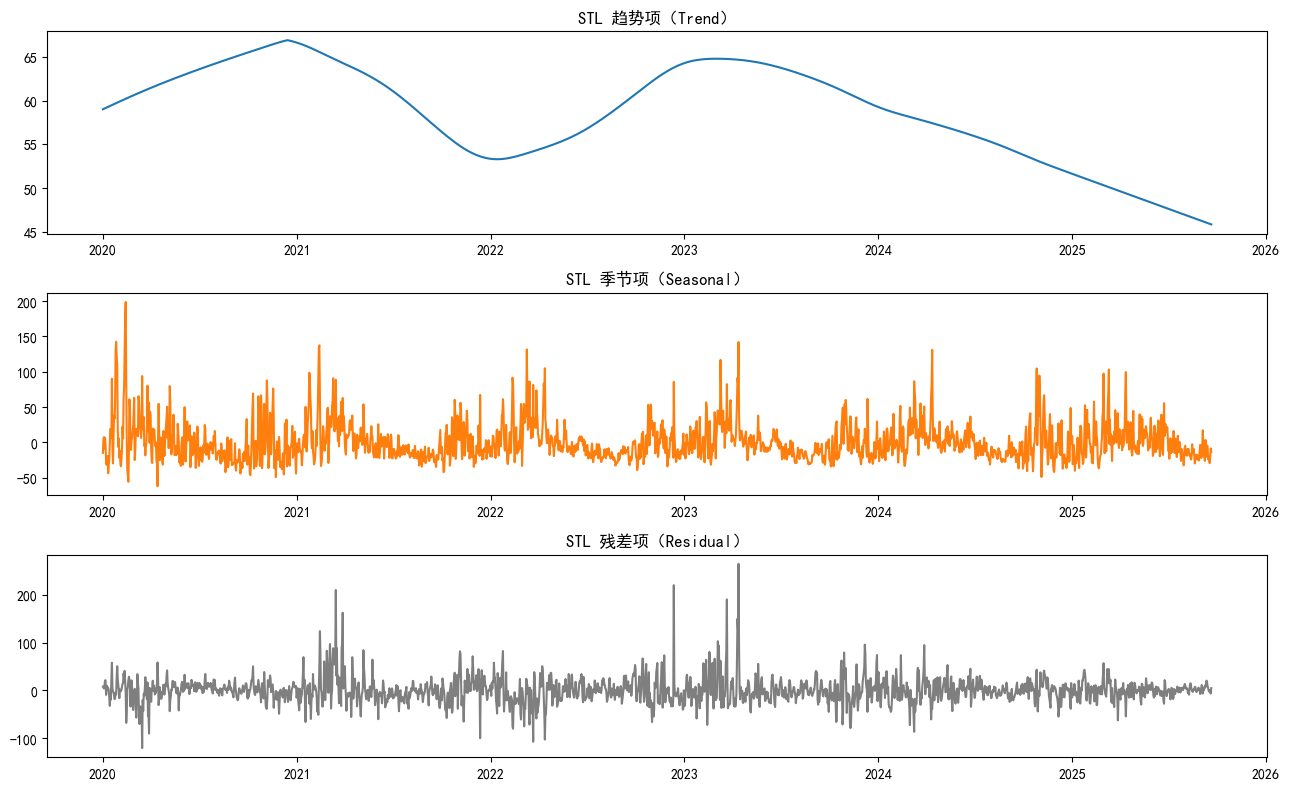

In [13]:
hist = city_df.copy()
hist = hist.groupby("date", as_index=False)["AQI"].mean().sort_values("date")
hist["MA7"] = hist["AQI"].rolling(7).mean()
hist["MA30"] = hist["AQI"].rolling(30).mean()
plt.rcParams['font.sans-serif'] = ['SimHei']  # Use a font that supports Chinese
plt.rcParams['axes.unicode_minus'] = False   # Correctly display minus signs
# 1) 趋势图
fig_trend = go.Figure()
fig_trend.add_trace(go.Scatter(x=hist["date"], y=hist["AQI"], name="AQI", line=dict(color="#666")))
fig_trend.add_trace(go.Scatter(x=hist["date"], y=hist["MA7"], name="7日均线", line=dict(color="#ff9900", width=2)))
fig_trend.add_trace(go.Scatter(x=hist["date"], y=hist["MA30"], name="30日均线", line=dict(color="#0072ff", width=2)))
fig_trend.update_layout(
    template="plotly_white",
    height=520,
    title=f"{CITY} 历史 AQI 趋势图",
    xaxis_title="日期",
    yaxis_title="AQI",
    legend_title="图例",
)
fig_trend.show()

# 2) 月度热力图（含 AQI 数字）
h = hist.copy()
h["year"] = h["date"].dt.year
h["month"] = h["date"].dt.month
pivot = h.groupby(["year", "month"], as_index=False)["AQI"].mean().pivot(index="year", columns="month", values="AQI")

fig_heat = go.Figure(
    data=go.Heatmap(
        z=pivot.values,
        x=pivot.columns,
        y=pivot.index,
        colorscale="RdYlGn_r",
        colorbar=dict(title="AQI"),
    )
)

for i, yv in enumerate(pivot.index):
    for j, xv in enumerate(pivot.columns):
        val = pivot.values[i][j]
        if pd.notna(val):
            fig_heat.add_annotation(
                x=xv,
                y=yv,
                text=f"{val:.0f}",
                showarrow=False,
                font=dict(size=10, color="black"),
            )

fig_heat.update_layout(
    template="plotly_white",
    height=540,
    title=f"{CITY} 月度 AQI 热力图（含数值）",
    xaxis_title="月份",
    yaxis_title="年份",
)
fig_heat.show()

# 3) STL 分解
period = 365 if len(hist) >= 730 else max(14, int(len(hist)/2))
res = STL(hist.set_index("date")["AQI"], period=period).fit()

fig_stl = plt.figure(figsize=(13, 8))
ax1 = plt.subplot(3,1,1)
ax1.plot(res.trend.index, res.trend.values)
ax1.set_title("STL 趋势项（Trend）")
ax2 = plt.subplot(3,1,2)
ax2.plot(res.seasonal.index, res.seasonal.values, color="tab:orange")
ax2.set_title("STL 季节项（Seasonal）")
ax3 = plt.subplot(3,1,3)
ax3.plot(res.resid.index, res.resid.values, color="tab:gray")
ax3.set_title("STL 残差项（Residual）")
plt.tight_layout()
plt.show()

# 4) 星期 / 月份规律
h["weekday"] = h["date"].dt.weekday
h["month_label"] = h["month"].astype(str) + "月"
wd = h.groupby("weekday", as_index=False)["AQI"].mean()
wd["weekday_name"] = wd["weekday"].map({0:"周一",1:"周二",2:"周三",3:"周四",4:"周五",5:"周六",6:"周日"})
fig_wd = px.bar(wd.sort_values("weekday"), x="weekday_name", y="AQI", title="星期规律（平均 AQI）")
fig_wd.update_layout(template="plotly_white", height=420, xaxis_title="星期", yaxis_title="AQI")
fig_wd.show()

mo = h.groupby("month", as_index=False)["AQI"].mean().sort_values("month")
mo["month_label"] = mo["month"].astype(str) + "月"
fig_mo = px.line(mo, x="month_label", y="AQI", title="月份规律（平均 AQI）")
fig_mo.update_traces(mode="lines+markers")
fig_mo.update_layout(template="plotly_white", height=420, xaxis_title="月份", yaxis_title="AQI")
fig_mo.show()

## C. Predict 可视化（对应 `04_Predict.py`）

> 训练 Prophet，展示预测曲线、评估指标与组件分解。

In [14]:
p_df = preprocess_for_prophet(city_df)

split = int(len(p_df) * 0.8)
train_df = p_df.iloc[:split].copy()
test_df = p_df.iloc[split:].copy()

eval_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
eval_model.fit(train_df)
eval_future = eval_model.make_future_dataframe(periods=len(test_df), freq="D")
eval_fc = eval_model.predict(eval_future)
y_true = test_df["y"].values
y_pred = eval_fc["yhat"].iloc[-len(test_df):].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"城市={CITY} | MAE={mae:.2f} | RMSE={rmse:.2f} | R²={r2:.3f}")

# 全量训练 + 未来预测
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=CP_SCALE,
)
model.fit(p_df)
future = model.make_future_dataframe(periods=FORECAST_DAYS, freq="D")
forecast = model.predict(future)
for c in ["yhat", "yhat_lower", "yhat_upper"]:
    forecast[c] = forecast[c].clip(lower=0)

forecast_tail = forecast.tail(FORECAST_DAYS).copy()

# 主预测图（白色背景 + 中文）
fig_pred = go.Figure()
for lv in AQI_LEVELS:
    fig_pred.add_shape(
        type="rect",
        x0=p_df["ds"].min(),
        x1=forecast_tail["ds"].max(),
        y0=lv["min"],
        y1=lv["max"],
        fillcolor=lv["color"],
        line_width=0,
        layer="below",
    )

fig_pred.add_trace(go.Scatter(x=p_df["ds"], y=p_df["y"], name="历史数据", line=dict(color="#666", width=1.3)))
fig_pred.add_trace(go.Scatter(x=forecast_tail["ds"], y=forecast_tail["yhat"], name="预测趋势", line=dict(color="#FF4B4B", width=3)))
fig_pred.add_trace(go.Scatter(x=forecast_tail["ds"], y=forecast_tail["yhat_upper"], mode="lines", line=dict(width=0), showlegend=False))
fig_pred.add_trace(go.Scatter(x=forecast_tail["ds"], y=forecast_tail["yhat_lower"], fill="tonexty", fillcolor="rgba(255,75,75,0.15)", line=dict(width=0), name="置信区间"))
fig_pred.update_layout(
    template="plotly_white",
    height=650,
    title=f"{CITY} 未来 {FORECAST_DAYS} 天 AQI 预测",
    xaxis_title="日期",
    yaxis_title="AQI",
    legend_title="图例",
)
fig_pred.show()

# 指标表（中文）
metrics_df = pd.DataFrame([
    {"评估指标": "MAE", "数值": round(mae, 3)},
    {"评估指标": "RMSE", "数值": round(rmse, 3)},
    {"评估指标": "R²", "数值": round(r2, 3)},
])
display(metrics_df)

23:46:02 - cmdstanpy - INFO - Chain [1] start processing
23:46:02 - cmdstanpy - INFO - Chain [1] done processing


城市=北京 | MAE=20.60 | RMSE=27.26 | R²=0.126


23:46:03 - cmdstanpy - INFO - Chain [1] start processing
23:46:04 - cmdstanpy - INFO - Chain [1] done processing


,评估指标,数值
0,MAE,20.603
1,RMSE,27.255
2,R²,0.126


In [ ]:
# 自动调参：多组 Prophet 超参数对比并选择最优（按 RMSE）
import itertools
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 预处理 + 切分
p_df = preprocess_for_prophet(city_df)
split = int(len(p_df) * 0.8)
train_df = p_df.iloc[:split].copy()
test_df = p_df.iloc[split:].copy()

# 你要对比的超参数（可继续加）
param_grid = {
    "changepoint_prior_scale": [0.01, 0.05, 0.1, 0.3],
    "seasonality_prior_scale": [1.0, 5.0, 10.0],
    "yearly_seasonality": [True, False],
    "weekly_seasonality": [True, False],
    "daily_seasonality": [False],  # 日级数据一般先关掉 daily
}

keys = list(param_grid.keys())
param_combos = [dict(zip(keys, values)) for values in itertools.product(*(param_grid[k] for k in keys))]

results = []
for params in param_combos:
    try:
        eval_model = Prophet(**params)
        eval_model.fit(train_df)

        eval_future = eval_model.make_future_dataframe(periods=len(test_df), freq="D")
        eval_fc = eval_model.predict(eval_future)

        y_true = test_df["y"].values
        y_pred = eval_fc["yhat"].iloc[-len(test_df):].values

        mae_i = mean_absolute_error(y_true, y_pred)
        rmse_i = np.sqrt(mean_squared_error(y_true, y_pred))
        r2_i = r2_score(y_true, y_pred)

        results.append({
            **params,
            "MAE": mae_i,
            "RMSE": rmse_i,
            "R2": r2_i,
        })
    except Exception as e:
        results.append({
            **params,
            "MAE": np.nan,
            "RMSE": np.nan,
            "R2": np.nan,
            "error": str(e),
        })

results_df = pd.DataFrame(results).sort_values("RMSE", ascending=True, na_position="last").reset_index(drop=True)

print(f"共尝试参数组合: {len(param_combos)}")
display(results_df.head(10))

best_row = results_df.dropna(subset=["RMSE"]).iloc[0]
best_params = {
    "changepoint_prior_scale": float(best_row["changepoint_prior_scale"]),
    "seasonality_prior_scale": float(best_row["seasonality_prior_scale"]),
    "yearly_seasonality": bool(best_row["yearly_seasonality"]),
    "weekly_seasonality": bool(best_row["weekly_seasonality"]),
    "daily_seasonality": bool(best_row["daily_seasonality"]),
}

print("\n最优参数（按 RMSE 最小）:")
print(best_params)
print(f"最优验证指标: MAE={best_row['MAE']:.3f}, RMSE={best_row['RMSE']:.3f}, R²={best_row['R2']:.3f}")

# 用最优参数做全量训练，并输出未来预测（覆盖后续单元使用变量）
model = Prophet(**best_params)
model.fit(p_df)
future = model.make_future_dataframe(periods=FORECAST_DAYS, freq="D")
forecast = model.predict(future)
for c in ["yhat", "yhat_lower", "yhat_upper"]:
    forecast[c] = forecast[c].clip(lower=0)

forecast_tail = forecast.tail(FORECAST_DAYS).copy()

# 同步指标变量（便于后续复用）
mae = float(best_row["MAE"])
rmse = float(best_row["RMSE"])
r2 = float(best_row["R2"])

metrics_df = pd.DataFrame([
    {"评估指标": "MAE", "数值": round(mae, 3)},
    {"评估指标": "RMSE", "数值": round(rmse, 3)},
    {"评估指标": "R²", "数值": round(r2, 3)},
])
display(metrics_df)

In [15]:
# Prophet 组件拆解：趋势 / 周循环 / 年度季节性
comp_future = pd.DataFrame({"ds": pd.date_range(start=forecast_tail["ds"].min(), periods=365, freq="D")})
comp_fc = model.predict(comp_future)

# 趋势项 Trend
fig_t = go.Figure()
fig_t.add_trace(go.Scatter(x=comp_fc["ds"], y=comp_fc["trend"], line=dict(color="#8B5CF6", width=2), name="趋势项"))
fig_t.update_layout(
    template="plotly_white",
    height=420,
    title="Prophet 趋势项（Trend）",
    xaxis_title="日期",
    yaxis_title="趋势值",
    legend_title="图例",
)
fig_t.show()

# 周循环 Weekly
if "weekly" in comp_fc.columns:
    wd = comp_fc.copy()
    wd["weekday"] = wd["ds"].dt.weekday
    wd_avg = wd.groupby("weekday", as_index=False)["weekly"].mean()
    wd_avg["weekday_name"] = wd_avg["weekday"].map({0:"周一",1:"周二",2:"周三",3:"周四",4:"周五",5:"周六",6:"周日"})
    fig_w = px.bar(wd_avg.sort_values("weekday"), x="weekday_name", y="weekly", title="Prophet 周循环分量（Weekly）")
    fig_w.update_layout(template="plotly_white", height=380, xaxis_title="星期", yaxis_title="周效应值")
    fig_w.show()

# 年度季节性 Yearly
if "yearly" in comp_fc.columns:
    yr = comp_fc.copy()
    yr["month"] = yr["ds"].dt.month
    yr_avg = yr.groupby("month", as_index=False)["yearly"].mean().sort_values("month")
    yr_avg["month_label"] = yr_avg["month"].astype(str) + "月"
    fig_y = px.line(yr_avg, x="month_label", y="yearly", title="Prophet 年度季节性分量（Yearly）")
    fig_y.update_traces(mode="lines+markers")
    fig_y.update_layout(template="plotly_white", height=380, xaxis_title="月份", yaxis_title="年度季节效应值")
    fig_y.show()

# 未来区间等级分布
forecast_tail["level"] = forecast_tail["yhat"].apply(get_aqi_level)
level_counts = forecast_tail["level"].value_counts().reindex(AQI_LEVEL_ORDER, fill_value=0)
fig_level = px.pie(
    names=level_counts.index,
    values=level_counts.values,
    color=level_counts.index,
    color_discrete_map=AQI_LEVEL_COLOR,
    hole=0.5,
    title="未来预测 AQI 等级分布",
)
fig_level.update_layout(template="plotly_white", height=420)
fig_level.show()